# Red Neuronal para Predicción de Clima Marítimo
### Boya de Tarragona · Puertos del Estado

## - Importación de librerías - 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

In [5]:
import subprocess
subprocess.run(['pip', 'install', 'xarray', 'netCDF4'], capture_output=True)
print("✅ Librerías instaladas")

✅ Librerías instaladas


In [6]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Todas las librerías cargadas correctamente")
print(f"   TensorFlow: {tf.__version__}")
print(f"   NumPy:      {np.__version__}")
print(f"   Pandas:     {pd.__version__}")

✅ Todas las librerías cargadas correctamente
   TensorFlow: 2.21.0
   NumPy:      2.3.5
   Pandas:     2.3.3


## Carga de datos

In [7]:
import xarray as xr

# Ruta al archivo NetCDF de Copernicus
ruta_nc = 'cmems_mod_med_wav_anfc_4.2km_PT1H-i_1779024340119.nc'

# Abrimos el archivo
ds = xr.open_dataset(ruta_nc)

# Tomamos el punto central de la malla (índice 1,1)
lat_idx, lon_idx = 1, 1

# Construimos el DataFrame con las variables relevantes
df = pd.DataFrame({
    'fecha'        : ds.time.values,
    'altura_ola_m' : ds['VHM0'].values[:, lat_idx, lon_idx],
    'periodo_ola_s': ds['VTPK'].values[:, lat_idx, lon_idx],
    'dir_media'    : ds['VMDR'].values[:, lat_idx, lon_idx],
    'hm0_swell'    : ds['VHM0_SW1'].values[:, lat_idx, lon_idx],
    'hm0_viento'   : ds['VHM0_WW'].values[:, lat_idx, lon_idx],
})

df['fecha'] = pd.to_datetime(df['fecha'])
df = df.round(3)

print(f"✅ Datos reales cargados correctamente")
print(f"   Registros: {len(df):,}")
print(f"   Desde: {df['fecha'].min()}")
print(f"   Hasta: {df['fecha'].max()}")
print(f"   NaNs: {df.isnull().sum().sum()}")
df.head()

✅ Datos reales cargados correctamente
   Registros: 35,065
   Desde: 2022-05-26 11:00:00
   Hasta: 2026-05-26 11:00:00
   NaNs: 0


,fecha,altura_ola_m,periodo_ola_s,dir_media,hm0_swell,hm0_viento
0,2022-05-26 11:00:00,1.335,4.736,325.839996,0.732,1.103
1,2022-05-26 12:00:00,1.315,8.390,351.660004,0.872,0.573
2,2022-05-26 13:00:00,1.316,8.390,15.970000,0.979,0.552
3,2022-05-26 14:00:00,1.288,8.390,26.340000,1.006,0.790
4,2022-05-26 15:00:00,1.230,8.390,31.129999,0.979,0.730


## Exploración de datos

In [8]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"Rango temporal: {df['fecha'].min()} → {df['fecha'].max()}")
print()
df.describe().round(2)

Dimensiones del dataset: (35065, 6)
Rango temporal: 2022-05-26 11:00:00 → 2026-05-26 11:00:00



,fecha,altura_ola_m,periodo_ola_s,dir_media,hm0_swell,hm0_viento
count,35065,35065.00,35065.00,35065.00,35065.00,35065.00
mean,2024-05-25 23:00:00,0.86,5.33,163.93,0.55,0.45
min,2022-05-26 11:00:00,0.10,1.66,0.09,0.02,0.00
25%,2023-05-26 17:00:00,0.44,4.30,90.31,0.29,0.06
50%,2024-05-25 23:00:00,0.68,5.21,165.69,0.44,0.22
75%,2025-05-26 05:00:00,1.10,6.30,210.07,0.68,0.60
max,2026-05-26 11:00:00,4.65,13.51,359.90,3.56,4.53
std,NaN,0.59,1.64,81.10,0.37,0.58


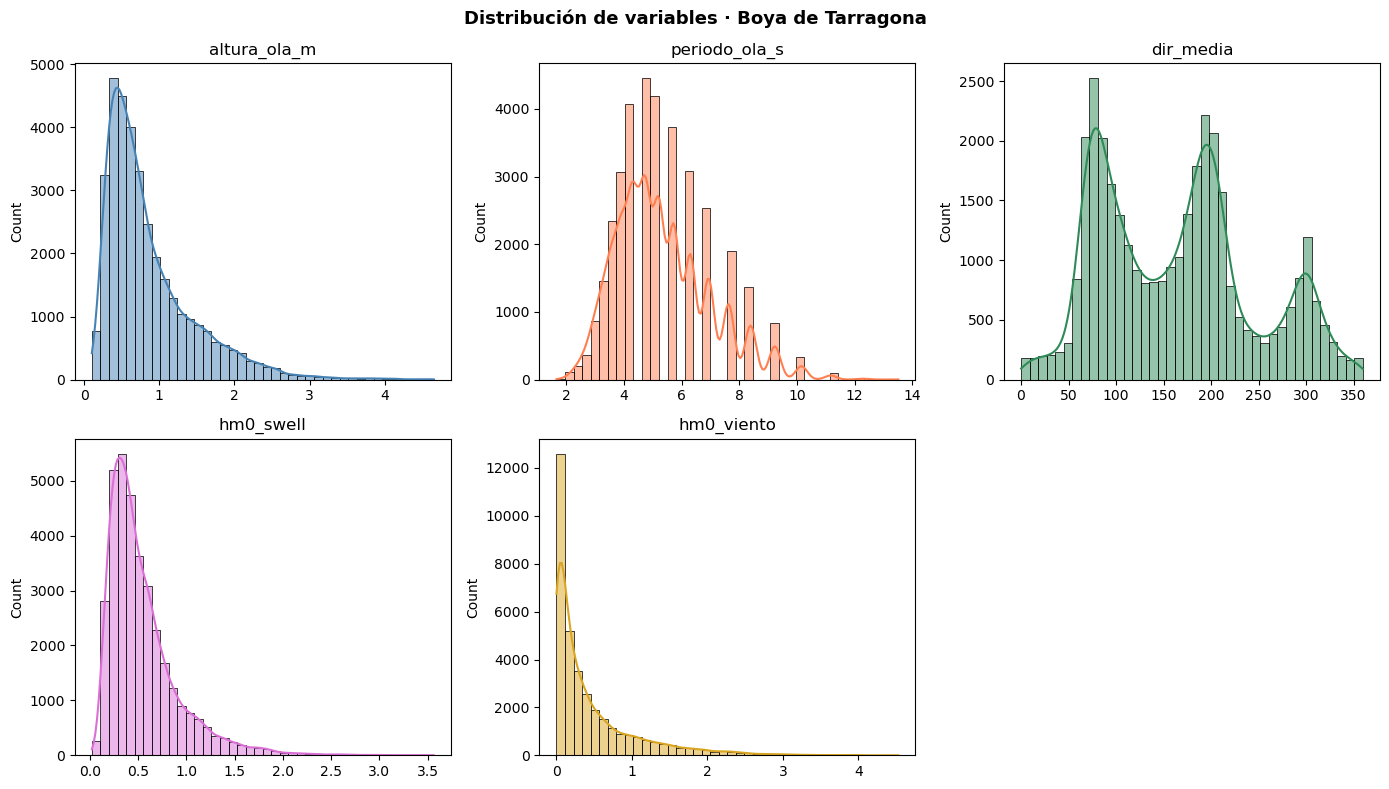

In [9]:
cols = ['altura_ola_m', 'periodo_ola_s', 'dir_media', 'hm0_swell', 'hm0_viento']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de variables · Boya de Tarragona', fontsize=13, fontweight='bold')
colores = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

for ax, col, color in zip(axes.flatten(), cols, colores):
    sns.histplot(df[col], ax=ax, color=color, kde=True, bins=40)
    ax.set_title(col)
    ax.set_xlabel('')

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

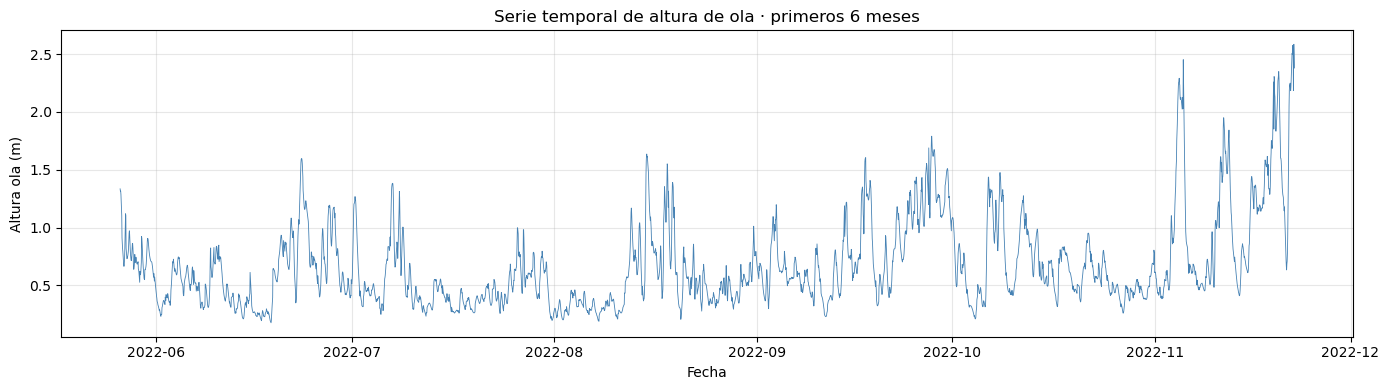

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['fecha'][:24*180], df['altura_ola_m'][:24*180],
        color='steelblue', linewidth=0.6)
ax.set_title('Serie temporal de altura de ola · primeros 6 meses')
ax.set_xlabel('Fecha')
ax.set_ylabel('Altura ola (m)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

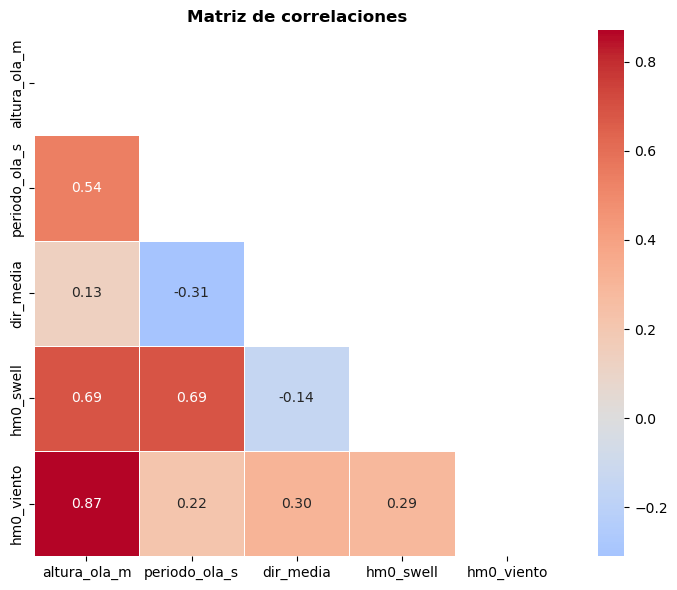

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax)

ax.set_title('Matriz de correlaciones', fontweight='bold')
plt.tight_layout()
plt.show()

## Procesamiento

In [12]:
print("Valores NaN por columna:")
print(df.isnull().sum())
print(f"\nTotal NaNs: {df.isnull().sum().sum()}")

Valores NaN por columna:
fecha            0
altura_ola_m     0
periodo_ola_s    0
dir_media        0
hm0_swell        0
hm0_viento       0
dtype: int64

Total NaNs: 0


In [13]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


In [14]:
# La variable objetivo es la altura de ola en t+1h
# shift(-1) desplaza la columna 1 posición hacia arriba
# → en cada fila tenemos los datos actuales para predecir la ola siguiente
df['target'] = df['altura_ola_m'].shift(-1)

# Eliminamos la última fila que queda sin valor de target
df.dropna(subset=['target'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Variable objetivo creada")
print(f"   Filas finales: {len(df):,}")
df[['fecha', 'altura_ola_m', 'target']].head()

✅ Variable objetivo creada
   Filas finales: 35,064


,fecha,altura_ola_m,target
0,2022-05-26 11:00:00,1.335,1.315
1,2022-05-26 12:00:00,1.315,1.316
2,2022-05-26 13:00:00,1.316,1.288
3,2022-05-26 14:00:00,1.288,1.230
4,2022-05-26 15:00:00,1.230,1.164


In [16]:
FEATURE_COLS = [
    'altura_ola_m',
    'periodo_ola_s',
    'dir_media',
    'hm0_swell',
    'hm0_viento'
]

X = df[FEATURE_COLS].values
y = df['target'].values

print(f"X (features): {X.shape}")
print(f"y (target):   {y.shape}")

X (features): (35064, 5)
y (target):   (35064,)


In [17]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Primero dividimos, luego normalizamos
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.15, shuffle=False, random_state=SEED
)

# fit_transform en train
X_train_s = scaler_X.fit_transform(X_train_raw)
y_train_s = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).ravel()

# solo transform en test
X_test_s = scaler_X.transform(X_test_raw)
y_test_s = scaler_y.transform(y_test_raw.reshape(-1,1)).ravel()

print(f"Train: {X_train_s.shape[0]:,} muestras")
print(f"Test:  {X_test_s.shape[0]:,} muestras")
print(f"\nMedia X_train tras normalizar: {X_train_s.mean(axis=0).round(3)}")

Train: 29,804 muestras
Test:  5,260 muestras

Media X_train tras normalizar: [ 0.  0. -0.  0.  0.]


## Construcción de la Red Neuronal

In [18]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(5,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

t_inicio = time.time()

history = model.fit(
    X_train_s, y_train_s,
    epochs=200,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

t_total = time.time() - t_inicio
print(f"\n✅ Entrenamiento completado en {t_total:.1f} segundos")
print(f"   Épocas ejecutadas: {len(history.history['loss'])}")

Epoch 1/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1376 - mae: 0.2228 - val_loss: 0.0144 - val_mae: 0.0918
Epoch 2/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0422 - mae: 0.1399 - val_loss: 0.0187 - val_mae: 0.1080
Epoch 3/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0338 - mae: 0.1226 - val_loss: 0.0243 - val_mae: 0.1236
Epoch 4/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0288 - mae: 0.1122 - val_loss: 0.0374 - val_mae: 0.1523
Epoch 5/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0262 - mae: 0.1060 - val_loss: 0.0291 - val_mae: 0.1277
Epoch 6/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0233 - mae: 0.1001 - val_loss: 0.0343 - val_mae: 0.1439
Epoch 7/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0224 - mae: 0.0966 - val_loss: 0.0331 - val_mae: 0.1388
Epoch 8/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0214 - mae: 0.0939 - val_loss: 0.0307 - val_mae: 0.1366
Epoch 9/200
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

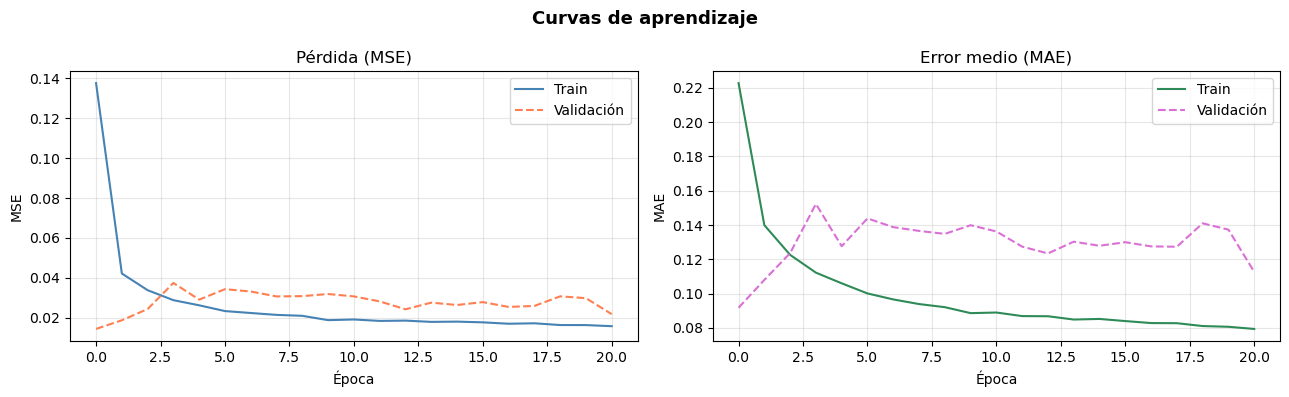

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train',      color='steelblue')
ax1.plot(history.history['val_loss'], label='Validación', color='coral', ls='--')
ax1.set_title('Pérdida (MSE)')
ax1.set_xlabel('Época')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['mae'],     label='Train',      color='seagreen')
ax2.plot(history.history['val_mae'], label='Validación', color='orchid', ls='--')
ax2.set_title('Error medio (MAE)')
ax2.set_xlabel('Época')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Curvas de aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluación del modelo

In [21]:
y_pred_s = model.predict(X_test_s).ravel()

y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()
y_real = scaler_y.inverse_transform(y_test_s.reshape(-1,1)).ravel()

mse  = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_real, y_pred)
r2   = r2_score(y_real, y_pred)
r    = np.corrcoef(y_real, y_pred)[0,1]
bias = np.mean(y_pred - y_real)

print("════════════════════════════════")
print("  MÉTRICAS DE EVALUACIÓN")
print("════════════════════════════════")
print(f"  MSE  = {mse:.4f} m²")
print(f"  RMSE = {rmse:.4f} m")
print(f"  MAE  = {mae:.4f} m")
print(f"  R²   = {r2:.4f}")
print(f"  R    = {r:.4f}")
print(f"  Bias = {bias:+.4f} m")
print("════════════════════════════════")

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
════════════════════════════════
  MÉTRICAS DE EVALUACIÓN
════════════════════════════════
  MSE  = 0.0150 m²
  RMSE = 0.1225 m
  MAE  = 0.0837 m
  R²   = 0.9688
  R    = 0.9921
  Bias = -0.0299 m
════════════════════════════════


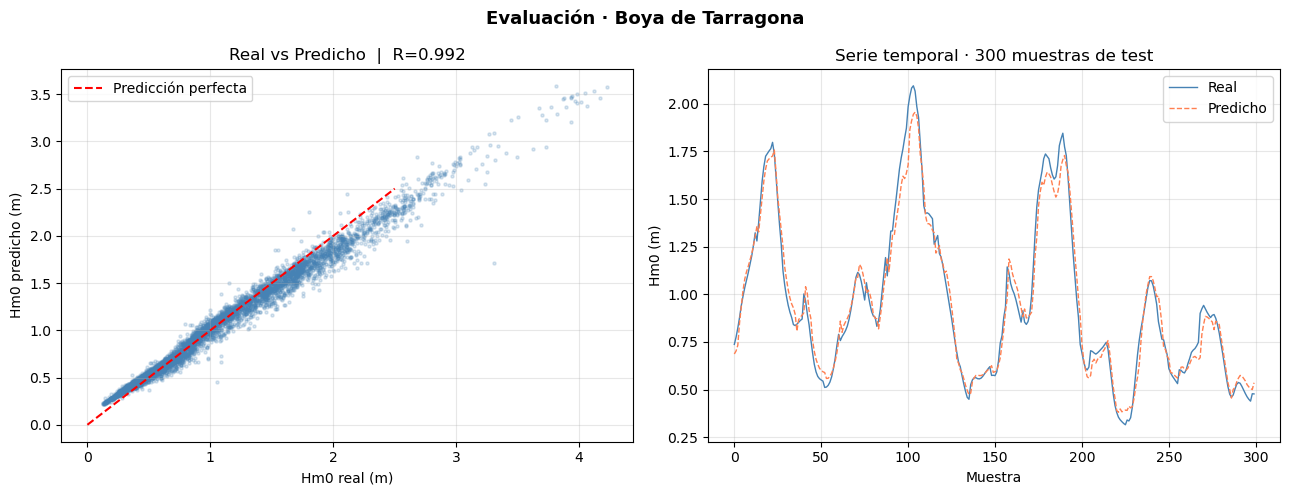

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter real vs predicho
ax1.scatter(y_real, y_pred, alpha=0.2, color='steelblue', s=5)
lim = [0, 2.5]
ax1.plot(lim, lim, 'r--', lw=1.5, label='Predicción perfecta')
ax1.set_xlabel('Hm0 real (m)')
ax1.set_ylabel('Hm0 predicho (m)')
ax1.set_title(f'Real vs Predicho  |  R={r:.3f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Serie temporal primeras 300 muestras
ax2.plot(y_real[:300],  color='steelblue', lw=1,   label='Real')
ax2.plot(y_pred[:300],  color='coral',     lw=1, ls='--', label='Predicho')
ax2.set_xlabel('Muestra')
ax2.set_ylabel('Hm0 (m)')
ax2.set_title('Serie temporal · 300 muestras de test')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Evaluación · Boya de Tarragona', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
model.save('modelo_tarragona.keras')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("✅ Modelo guardado: 'modelo_tarragona.keras'")
print("✅ Scalers guardados: 'scaler_X.pkl', 'scaler_y.pkl'")
print()
print("Para cargar en el futuro:")
print("  model    = keras.models.load_model('modelo_tarragona.keras')")
print("  scaler_X = joblib.load('scaler_X.pkl')")
print("  scaler_y = joblib.load('scaler_y.pkl')")

✅ Modelo guardado: 'modelo_tarragona.keras'
✅ Scalers guardados: 'scaler_X.pkl', 'scaler_y.pkl'

Para cargar en el futuro:
  model    = keras.models.load_model('modelo_tarragona.keras')
  scaler_X = joblib.load('scaler_X.pkl')
  scaler_y = joblib.load('scaler_y.pkl')


## Validación cruzada K-Fold (K=10)

In [24]:
kf = KFold(n_splits=10, shuffle=False)

rmse_folds = []
mae_folds  = []

print("Ejecutando K-Fold con K=10...")

for fold_i, (train_idx, val_idx) in enumerate(kf.split(X)):
    Xf_tr  = scaler_X.fit_transform(X[train_idx])
    Xf_val = scaler_X.transform(X[val_idx])
    yf_tr  = scaler_y.fit_transform(y[train_idx].reshape(-1,1)).ravel()
    yf_val = y[val_idx]

    m = Sequential([
        Dense(64, activation='relu', input_shape=(5,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1,  activation='linear')
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(Xf_tr, yf_tr, epochs=30, batch_size=64, verbose=0)

    yp = scaler_y.inverse_transform(m.predict(Xf_val, verbose=0).reshape(-1,1)).ravel()

    rmse_folds.append(np.sqrt(mean_squared_error(yf_val, yp)))
    mae_folds.append(mean_absolute_error(yf_val, yp))
    print(f"  Fold {fold_i+1:2d}/10 → RMSE={rmse_folds[-1]:.4f}  MAE={mae_folds[-1]:.4f}")

print()
print(f"RMSE medio: {np.mean(rmse_folds):.4f} ± {np.std(rmse_folds):.4f} m")
print(f"MAE  medio: {np.mean(mae_folds):.4f} ± {np.std(mae_folds):.4f} m")

Ejecutando K-Fold con K=10...
  Fold  1/10 → RMSE=0.0834  MAE=0.0729
  Fold  2/10 → RMSE=0.1742  MAE=0.1180
  Fold  3/10 → RMSE=0.0960  MAE=0.0824
  Fold  4/10 → RMSE=0.1448  MAE=0.1166
  Fold  5/10 → RMSE=0.1455  MAE=0.1085
  Fold  6/10 → RMSE=0.0954  MAE=0.0775
  Fold  7/10 → RMSE=0.1551  MAE=0.1075
  Fold  8/10 → RMSE=0.1071  MAE=0.0919
  Fold  9/10 → RMSE=0.1216  MAE=0.0970
  Fold 10/10 → RMSE=0.1710  MAE=0.1305

RMSE medio: 0.1294 ± 0.0314 m
MAE  medio: 0.1003 ± 0.0181 m
